# Sample CMIP6 Data

This notebook demonstrates how to access CMIP6 data on JASMIN via the CEDA Archive. As an example, it uses UKESM1‑0‑LL SSP585 and SSP534-over projections and historical simulation to create a sample dataset. The workflow reads monthly model output, computes annual‑mean fields and globally-averaged data, and saves the processed data to NetCDF files for downstream analysis.

- All CMIP6 data is stored at `/badc/cmip6/data/CMIP6/`.
- UKESM1-0-LL SSP585 output is at `/badc/cmip6/data/CMIP6/ScenarioMIP/MOHC/UKESM1-0-LL/ssp585/`.
- UKESM1-0-LL SSP534-over output is at `/badc/cmip6/data/CMIP6/ScenarioMIP/MOHC/UKESM1-0-LL/ssp534-over/`.
- UKESM1-0-LL historical output is at `/badc/cmip6/data/CMIP6/CMIP/MOHC/UKESM1-0-LL/historical/`.

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

import warnings
warnings.filterwarnings("ignore")

In [2]:
dir_path = "/badc/cmip6/data/CMIP6/" # this is the directory for all cmip6 output

# ------ read ukesm-0-ll data (near-surface temperature, 'tas' diagnostic) ------------
# here, we use r1i1p1f2 ensemble member for testing. Ideally, we would use the mean of all ensemble members.

ds_ssp585 = xr.open_mfdataset(dir_path + "ScenarioMIP/MOHC/UKESM1-0-LL/ssp585/r1i1p1f2/Amon/tas/gn/latest/*nc") # 2015-2100 (starting from historical end)
ds_ssp534over = xr.open_mfdataset(dir_path + "ScenarioMIP/MOHC/UKESM1-0-LL/ssp534-over/r1i1p1f2/Amon/tas/gn/latest/*nc") # 2040-2100 (branching from ssp585)
ds_hist = xr.open_mfdataset(dir_path + "CMIP/MOHC/UKESM1-0-LL/historical/r1i1p1f2/Amon/tas/gn/latest/*nc") # 1850-2014 run

In [3]:
print(ds_ssp585)

<xarray.Dataset> Size: 120MB
Dimensions:    (time: 1032, bnds: 2, lat: 144, lon: 192)
Coordinates:
  * time       (time) object 8kB 2015-01-16 00:00:00 ... 2100-12-16 00:00:00
  * lat        (lat) float64 1kB -89.38 -88.12 -86.88 ... 86.88 88.12 89.38
  * lon        (lon) float64 2kB 0.9375 2.812 4.688 6.562 ... 355.3 357.2 359.1
    height     float64 8B 1.5
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) object 17kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    lat_bnds   (time, lat, bnds) float64 2MB dask.array<chunksize=(420, 144, 2), meta=np.ndarray>
    lon_bnds   (time, lon, bnds) float64 3MB dask.array<chunksize=(420, 192, 2), meta=np.ndarray>
    tas        (time, lat, lon) float32 114MB dask.array<chunksize=(1, 144, 192), meta=np.ndarray>
Attributes: (12/46)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            ScenarioMIP
    branch_method:          standard
    branch_time_in_child:   59400.0
    branch_time_in_parent: 

In [4]:
# Compute annual-means

days = ds_ssp585['time'].dt.days_in_month
weights = days.groupby('time.year') / days.groupby('time.year').sum(dim='time')
ds_ssp585 = (ds_ssp585.get(['tas']) * weights).groupby('time.year').sum(dim='time') 

days = ds_ssp534over['time'].dt.days_in_month
weights = days.groupby('time.year') / days.groupby('time.year').sum(dim='time')
ds_ssp534over = (ds_ssp534over.get(['tas']) * weights).groupby('time.year').sum(dim='time') 

days = ds_hist['time'].dt.days_in_month
weights = days.groupby('time.year') / days.groupby('time.year').sum(dim='time')
ds_hist = (ds_hist.get(['tas']) * weights).groupby('time.year').sum(dim='time') 

print(ds_ssp585)

<xarray.Dataset> Size: 19MB
Dimensions:  (year: 86, lat: 144, lon: 192)
Coordinates:
  * lat      (lat) float64 1kB -89.38 -88.12 -86.88 -85.62 ... 86.88 88.12 89.38
  * lon      (lon) float64 2kB 0.9375 2.812 4.688 6.562 ... 355.3 357.2 359.1
  * year     (year) int64 688B 2015 2016 2017 2018 2019 ... 2097 2098 2099 2100
Data variables:
    tas      (year, lat, lon) float64 19MB dask.array<chunksize=(1, 144, 192), meta=np.ndarray>


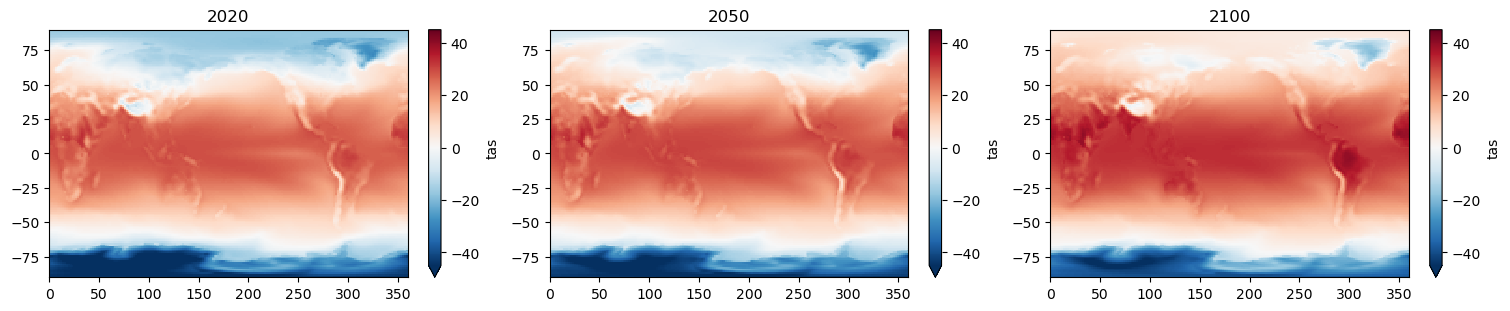

In [7]:
# plot (SSP585 raw temperatures in Deg C)
years = [2020, 2050, 2100]

fig, axes = plt.subplots(ncols=3, figsize=(15, 3), constrained_layout=True)

for ax, year in zip(axes, years):
    tas_year = ds_ssp585["tas"].sel(year=year, method="nearest") - 273.15
    
    tas_year.plot(ax=ax, cmap="RdBu_r", add_colorbar=True, vmin = -45.0, vmax = 45.0) 
    ax.set_title(str(year))
    ax.set_xlabel("")
    ax.set_ylabel("")

### Temperature Anomalies and Global-mean

Ideally, we would like to analyse anomalies with respect to historical period. Here, we compute temperature anomalies with respect to 1850-1900 mean. Also, we compute globally-averaged temperature anomalies.

In [8]:
# Compute anomalies wrt 1850-1900 mean

ds_ssp585 = (ds_ssp585 - ds_hist.sel(year=slice(1850, 1900)).mean('year')).compute()
ds_ssp534over = (ds_ssp534over - ds_hist.sel(year=slice(1850, 1900)).mean('year')).compute()
ds_hist = (ds_hist - ds_hist.sel(year=slice(1850, 1900)).mean('year')).compute()

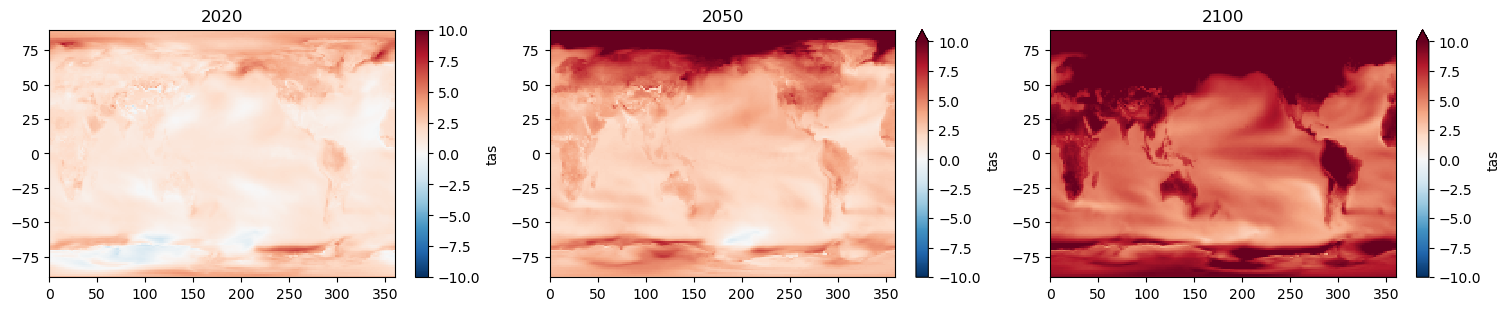

In [9]:
# plot (SSP585 temperature anomalies)
years = [2020, 2050, 2100]

fig, axes = plt.subplots(ncols=3, figsize=(15, 3), constrained_layout=True)

for ax, year in zip(axes, years):
    tas_year = ds_ssp585["tas"].sel(year=year, method="nearest")
    
    tas_year.plot(ax=ax, cmap="RdBu_r", add_colorbar=True, vmin = -10.0, vmax = 10.0)
    
    ax.set_title(str(year))
    ax.set_xlabel("")
    ax.set_ylabel("")

In [10]:
# Compute globa-mean tas anomalies

def compute_grid_areas(ds, var, x='X', y='Y', RAD_EARTH = 6.387e6):

    """Compute grid-cell areas
    Parameters
    ----------
    ds : xarray Dataset for data variables
    
    Returns
    -------
    Cell_area : grid cell areas
    """

    ds = ds.copy()

    dx = np.mean(ds[x].diff(x)) * np.cos(ds[y] * np.pi / 180.) * (2 * np.pi * RAD_EARTH / 360.)
    dy = np.mean(ds[y].diff(y)) * (2 * np.pi * RAD_EARTH / 360.)

    Cell_area = dx * dy

    Cell_area, tmp = xr.broadcast(Cell_area, var)

    return Cell_area

In [11]:
# For globa-mean quantities, we first need to compute grid cell areas and then calculate area-weighted mean
RAD_EARTH = 6.387e6

for ds in [ds_ssp585, ds_ssp534over, ds_hist]:
    dA = compute_grid_areas(ds, ds['tas'].isel(year=0),
                            x='lon', y='lat', RAD_EARTH = RAD_EARTH) # grid cell areas for area-integration

    tas_avg = (ds['tas'] *  dA).sum(['lat', 'lon']) / dA.sum(['lat', 'lon'])
    ds['tas_global'] = tas_avg.compute()

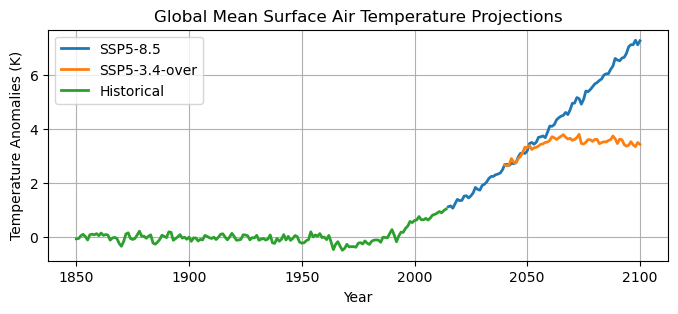

In [14]:
plt.figure(figsize=(8, 3))


scenarios = {
    "SSP5-8.5": ds_ssp585,
    "SSP5-3.4-over": ds_ssp534over,
    "Historical": ds_hist
}

for label, ds in scenarios.items():
    plt.plot(ds['year'], ds['tas_global'], lw= 2., label=label)


# Axis labels
plt.xlabel("Year")
plt.ylabel("Temperature Anomalies (K)")

# Title
plt.title("Global Mean Surface Air Temperature Projections")

# Legend
plt.legend()
plt.grid('on')

In [15]:
# Save Data

ds_ssp585.astype(np.float32).to_netcdf("./sample-ssp585.nc")
ds_ssp534over.astype(np.float32).to_netcdf("./sample-ssp534-over.nc")
ds_hist.astype(np.float32).to_netcdf("./sample-hist.nc")